# Step 011.3A — Compatibility Scoring, Ranking and Controlled Gates

This executed notebook presents VIS-003 and VIS-009 validation evidence plus the explicit VIS-002, VIS-006, and VIS-007 gates. All scores are derived from scalar compatibility functions, preserving pair reversal algebraically. The locked test split remains unused.


In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display
ROOT = Path.cwd()
VISION = ROOT / "reports" / "course_coverage" / "vision"
comparison = pd.read_csv(VISION / "compatibility_strategy_comparison.csv")
display(comparison)


,strategy,run_count,validation_macro_f1_mean,validation_macro_f1_std,validation_accuracy_mean,pairwise_ranking_accuracy_mean,three_way_ordering_accuracy_mean,equal_pair_accuracy_mean,parameter_count,inference_time_ms_mean,selected_strategy
0,class_probability_expected_score,3,0.817552,0.0,0.816667,0.883333,0.80,0.666667,111,0.003434,True
1,ordinal_ridge,3,0.817552,0.0,0.816667,0.866667,0.75,0.600000,37,0.003123,False


## VIS-003 — Ordered compatibility scores


In [2]:
predictions = pd.read_csv(VISION / "compatibility_validation_predictions.csv")
display(predictions.head(12))
display(predictions.groupby("true_label")["compatibility_score"].agg(["count", "mean", "std", "min", "max"]))


,sample_id,image_id,part_group_id,part_family,part_category,description,true_label,source,description_category,compatibility_score,predicted_label,strategy,seed,correct
0,air_filter_004_01_match,air_filter_004_01,air_filter_004,filtration,air_filter,Automotive air filter.,MATCH,generated_development,air_filter,0.977989,MATCH,class_probability_expected_score,42,True
1,air_filter_004_01_mismatch,air_filter_004_01,air_filter_004,filtration,air_filter,Automotive starter motor.,MISMATCH,generated_development,starter,0.014972,MISMATCH,class_probability_expected_score,42,True
2,air_filter_004_01_partial_match,air_filter_004_01,air_filter_004,filtration,air_filter,Automotive oil filter.,PARTIAL_MATCH,generated_development,oil_filter,0.494991,PARTIAL_MATCH,class_probability_expected_score,42,True
3,alternator_004_01_match,alternator_004_01,alternator_004,electrical,alternator,Automotive alternator.,MATCH,generated_development,alternator,0.992931,MATCH,class_probability_expected_score,42,True
4,alternator_004_01_mismatch,alternator_004_01,alternator_004,electrical,alternator,Automotive brake disc.,MISMATCH,generated_development,brake_disc,0.007761,MISMATCH,class_probability_expected_score,42,True
5,alternator_004_01_partial_match,alternator_004_01,alternator_004,electrical,alternator,Automotive starter motor.,PARTIAL_MATCH,generated_development,starter,0.497767,PARTIAL_MATCH,class_probability_expected_score,42,True
6,brake_disc_004_01_match,brake_disc_004_01,brake_disc_004,braking,brake_disc,Automotive brake disc.,MATCH,generated_development,brake_disc,0.989898,MATCH,class_probability_expected_score,42,True
7,brake_disc_004_01_mismatch,brake_disc_004_01,brake_disc_004,braking,brake_disc,Automotive shock absorber.,MISMATCH,generated_development,shock_absorber,0.010440,MISMATCH,class_probability_expected_score,42,True
8,brake_disc_004_01_partial_match,brake_disc_004_01,brake_disc_004,braking,brake_disc,Automotive brake pad set.,PARTIAL_MATCH,generated_development,brake_pad,0.499876,PARTIAL_MATCH,class_probability_expected_score,42,True
9,brake_pad_004_01_match,brake_pad_004_01,brake_pad_004,braking,brake_pad,Automotive brake pad set.,MATCH,generated_development,brake_pad,0.996407,MATCH,class_probability_expected_score,42,True


,count,mean,std,min,max
true_label,,,,,
MATCH,20,0.768508,0.399866,0.009787,0.996790
MISMATCH,20,0.037284,0.108144,0.004344,0.494940
PARTIAL_MATCH,20,0.425339,0.231918,0.006699,0.956753


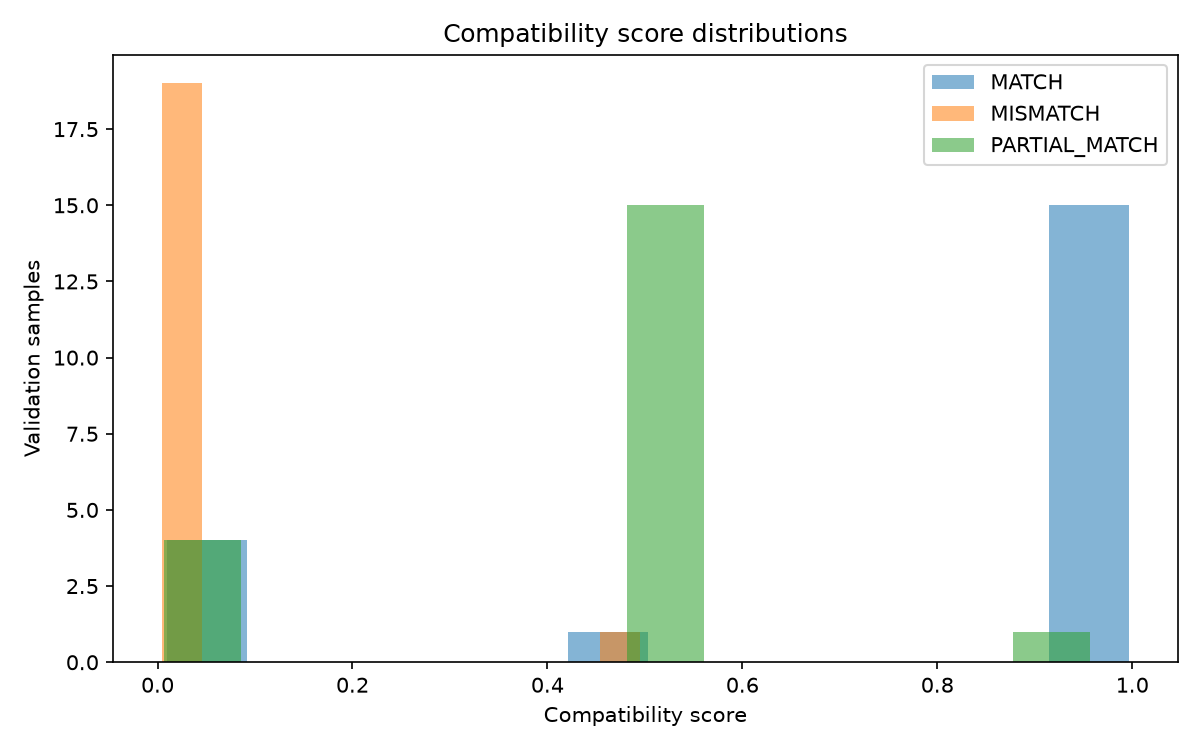

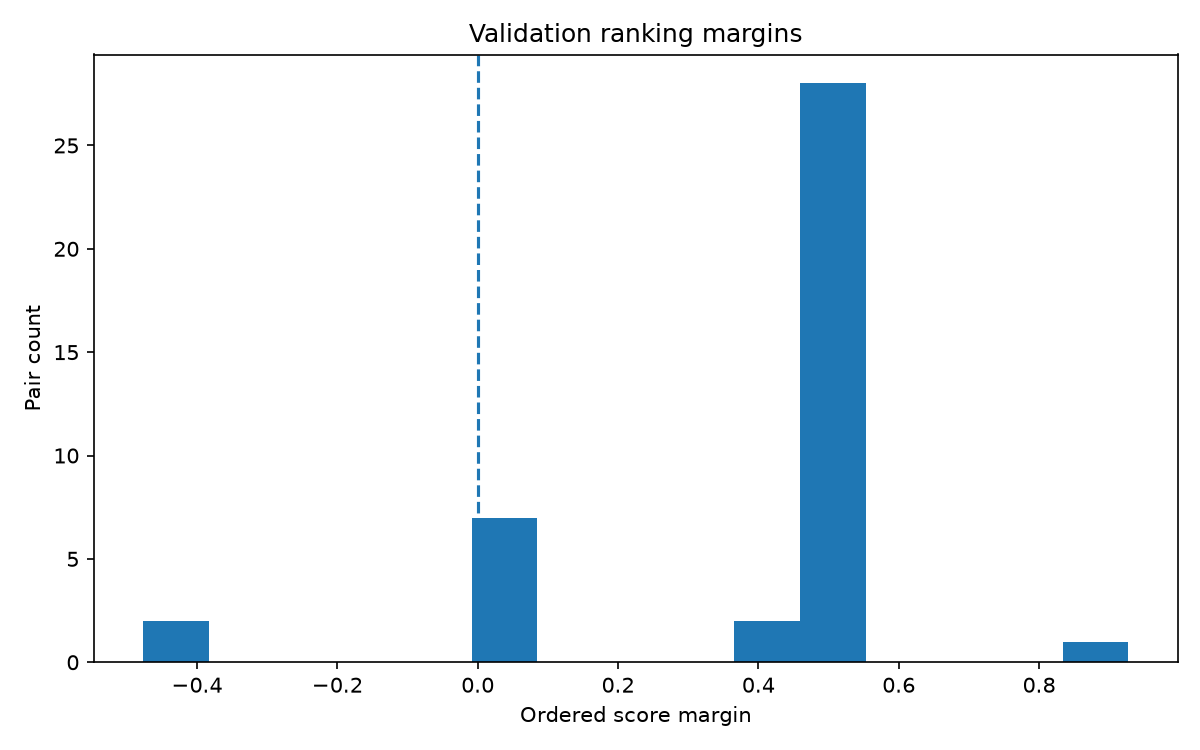

In [3]:
from PIL import Image
for name in ["compatibility_score_distribution.png", "ranking_margin_distribution.png"]:
    display(Image.open(VISION / "figures" / name))


## VIS-009 — Ranking consistency


In [4]:
ranking = json.loads((VISION / "ranking_metrics.json").read_text(encoding="utf-8-sig"))
triplets = pd.read_csv(VISION / "ranking_triplets.csv")
equal_pairs = pd.read_csv(VISION / "equal_pair_evaluation.csv")
ranking, display(triplets.head(12)), display(equal_pairs.head(12))


,image_id,part_category,source,match_score,partial_match_score,mismatch_score,match_partial_margin,partial_mismatch_margin,three_way_ordered,strategy
0,air_filter_004_01,air_filter,generated_development,0.977989,0.494991,0.014972,0.482998,0.480019,True,class_probability_expected_score
1,alternator_004_01,alternator,generated_development,0.992931,0.497767,0.007761,0.495164,0.490007,True,class_probability_expected_score
2,brake_disc_004_01,brake_disc,generated_development,0.989898,0.499876,0.010440,0.490022,0.489437,True,class_probability_expected_score
3,brake_pad_004_01,brake_pad,generated_development,0.996407,0.498545,0.004617,0.497863,0.493928,True,class_probability_expected_score
4,coil_spring_004_01,coil_spring,generated_development,0.991469,0.497858,0.014254,0.493611,0.483605,True,class_probability_expected_score
5,external_image_air_filter_475881,air_filter,wikimedia_commons_open_license,0.996790,0.498106,0.005695,0.498683,0.492412,True,class_probability_expected_score
6,external_image_alternator_12811841,alternator,wikimedia_commons_open_license,0.993367,0.497944,0.013869,0.495424,0.484075,True,class_probability_expected_score
7,external_image_brake_disc_36552019,brake_disc,wikimedia_commons_open_license,0.010420,0.015301,0.009380,-0.004880,0.005921,False,class_probability_expected_score
8,external_image_brake_pad_2470132,brake_pad,wikimedia_commons_open_license,0.983492,0.494686,0.015831,0.488806,0.478855,True,class_probability_expected_score
9,external_image_coil_spring_4525127,coil_spring,wikimedia_commons_open_license,0.048516,0.037075,0.032693,0.011441,0.004383,True,class_probability_expected_score


,label,left_sample_id,right_sample_id,left_score,right_score,absolute_difference,tie_threshold,predicted_tie,flip_consistency_error,strategy
0,MATCH,air_filter_004_01_match,alternator_004_01_match,0.977989,0.992931,0.014943,0.05,True,0.0,class_probability_expected_score
1,MATCH,brake_disc_004_01_match,brake_pad_004_01_match,0.989898,0.996407,0.006509,0.05,True,0.0,class_probability_expected_score
2,MATCH,coil_spring_004_01_match,external_sample_air_filter_475881_match,0.991469,0.996790,0.005321,0.05,True,0.0,class_probability_expected_score
3,MATCH,external_sample_alternator_12811841_match,external_sample_brake_disc_36552019_match,0.993367,0.010420,0.982947,0.05,False,0.0,class_probability_expected_score
4,MATCH,external_sample_brake_pad_2470132_match,external_sample_coil_spring_4525127_match,0.983492,0.048516,0.934976,0.05,False,0.0,class_probability_expected_score
5,MATCH,external_sample_headlight_2983638_match,external_sample_oil_filter_1715177_match,0.012467,0.488528,0.476061,0.05,False,0.0,class_probability_expected_score
6,MATCH,external_sample_shock_absorber_551757_match,external_sample_starter_1650046_match,0.920225,0.983986,0.063761,0.05,False,0.0,class_probability_expected_score
7,MATCH,external_sample_taillight_4518332_match,headlight_004_01_match,0.009787,0.994508,0.984721,0.05,False,0.0,class_probability_expected_score
8,MATCH,oil_filter_004_01_match,shock_absorber_004_01_match,0.994540,0.995702,0.001162,0.05,True,0.0,class_probability_expected_score
9,MATCH,starter_004_01_match,taillight_004_01_match,0.994985,0.994145,0.000841,0.05,True,0.0,class_probability_expected_score


({'step': '011.3A',
  'status': 'PASS',
  'selected_run_id': 'VIS003_class_probability_expected_score_seed42',
  'selected_strategy': 'class_probability_expected_score',
  'seed': 42,
  'validation_macro_f1': 0.8175515941473388,
  'validation_accuracy': 0.8166666666666667,
  'equal_pair_threshold_fit_split': 'train_only',
  'equal_pair_threshold': 0.05,
  'scalar_score_guarantees_antisymmetric_pair_differences': True,
  'scalar_score_guarantees_transitive_ordering': True,
  'parameter_count': 111,
  'inference_time_ms': 0.003615000120286519,
  'pairwise_ranking_accuracy': 0.8833333333333333,
  'three_way_ordering_accuracy': 0.8,
  'cycle_consistency': 1.0,
  'flip_consistency_error': 0.0,
  'equal_pair_accuracy': 0.6666666666666666,
  'mean_pairwise_margin': 0.48748214717100685,
  'minimum_pairwise_margin': -0.4824731615372002,
  'triplet_count': 20,
  'pairwise_comparison_count': 60,
  'equal_pair_count': 30,
  'locked_test_csv_files_opened': False,
  'test_split_used': False,
  'fina

## Controlled gates


In [5]:
gates = {
    name: json.loads((VISION / name).read_text(encoding="utf-8-sig"))
    for name in [
        "pretrained_backbone_gate.json",
        "fine_tuning_gate.json",
        "human_annotation_gate.json",
    ]
}
gates


{'pretrained_backbone_gate.json': {'step': '011.3A',
  'experiment_id': 'VIS-002',
  'status': 'DEFERRED_EXPLICIT_APPROVAL_REQUIRED',
  'approval_received': False,
  'network_download_attempted': False,
  'pretrained_weights_downloaded': False,
  'model_identifiers': [],
  'license_revisions_recorded': False,
  'reason': 'Frozen convolutional and vision-transformer backbones require explicit approval before downloads.',
  'locked_test_csv_files_opened': False,
  'test_split_used': False,
  'final_test_evaluation_authorized': False,
  'production_final_model_changed': False,
  'synthetic_human_agreement_reported': False},
 'fine_tuning_gate.json': {'step': '011.3A',
  'experiment_id': 'VIS-006',
  'status': 'DEFERRED_PRETRAINED_CHAMPION_AND_TIER4_APPROVAL_REQUIRED',
  'vis002_champion_available': False,
  'tier4_operator_approval_received': False,
  'fine_tuning_performed': False,
  'pretrained_weights_downloaded': False,
  'reason': 'Fine-tuning cannot begin before VIS-002 selects a fr

### Gate conclusion

VIS-002 and VIS-006 remain closed because pretrained model downloads and Tier 4 fine-tuning have not been authorized. VIS-007 remains closed because genuine independent annotators and pre-adjudication confidence labels do not yet exist. No synthetic annotator agreement is reported.
